In [ ]:
from google.colab import drive
drive.mount('/gdrive', force_remount = True)
!ls '/gdrive/My Drive/'
%cd '/gdrive/My Drive/'

Mounted at /gdrive
'Applied Physics.rar'		  DNN				      MyCV.pdf
'Assignment 1.gdoc'		  epoch_017.pt			      OHT1.rar
'Assignment 1.pdf'		  epoch_018.pt			      Project
'Colab Notebooks'		  epoch_019.pt			      ProjectBackUp
 Critic_512_A_BFL.pth		  epoch_020.pt			      SeeFar.rar
 Critic_64.pth			 'GDSC Assignment'		      state_007_sigma200.t7
 Critic_Optimizer_512_A_BFL.pth   Generator_512_A_BFL.pth	      TestDataset
 Critic_Optimizer_64.pth	  Generator_64.pth		      train_data
'CTScan GAN.ipynb'		  Generator_Optimizer_512_A_BFL.pth   UbuntuMachines.rar
 Dataset			  Generator_Optimizer_64.pth	     'Weapon Dataset'
'Dataset (1)'			 'Information Form.docx'	      YOLOv3
'Dataset (2)'			 'MuhammadDarabAhsan-AI ML.jpg'       YOLOv7
'Dataset (3)'			  MWDCNN			      yolov7-weapon27
'Diffusion DeNoising'		 'My_CV (5).pdf'
/gdrive/My Drive


In [ ]:
# If any module gives error, then you have to install that first. Use the command
# !pip install MODULE_NAME

In [1]:
import torch
import math
import numpy as np
import random
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torch.nn.functional as F
import cv2
import os
import matplotlib.pyplot as plt

In [2]:
from keras.layers import Concatenate
import seaborn as sb
import os
from PIL import Image
from keras.layers import Input
import pandas as pd
import tensorflow as tf
import numpy as np
import cv2
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import MaxPooling2D, Flatten, Conv2D, Dense, BatchNormalization, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.densenet import DenseNet169
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

In [3]:
trained = True
epochs = 11
display_step = 745
img_channels = 3
crit_repeats = 5
gen_repeats = 1
learning_rate_D = 0.0002
learning_rate_G = 0.0002
beta_1 = 0.9
beta_2 = 0.999
lambda_ = 10
z_dim = 128
device = 'cuda'
loss = 'BFL'
# For 128x128, size = (3, 128, 128)
size = (3, 512, 512)
# For 128x128, image_size = 128
image_size = 512
batch_size = 8

In [4]:
DATA_DIR = 'ProjectBackUp/Images/dataReal'
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

In [5]:
train_ds = ImageFolder(DATA_DIR, transform = T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)])
)

dataloader = DataLoader(
    train_ds,
    batch_size,
    shuffle = True,
    num_workers = 0,
    pin_memory = True
)

FileNotFoundError: Couldn't find any class folder in ProjectBackUp/Images/dataReal.

In [6]:
def show_tensor_images(image_tensor, num_images = 10, size = (3, 64, 64)):
    image_tensor = (image_tensor + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    image_grid = make_grid(image_unflat[:num_images], nrow = 5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [7]:
def generate_noise(n_examples, z_dim, device = 'cpu'):
    noise = torch.randn(n_examples, z_dim, device = device)
    return noise

In [8]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)

In [9]:
class Generator(nn.Module):
    def __init__(self, img_size, z_dim, n_channels):
        super(Generator, self).__init__()

        self.init_size = img_size // 4
        self.l1 = nn.Sequential(nn.Linear(z_dim, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor = 2),
            nn.Conv2d(128, 128, 3, stride = 1, padding = 1),
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Upsample(scale_factor = 2),
            nn.Conv2d(128, 64, 3, stride = 1, padding = 1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace = True),
            nn.Conv2d(64, n_channels, 3, stride = 1, padding = 1),
            nn.Tanh(),
        )

    def forward(self, z):
        out = self.l1(z)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

In [10]:
# Uncomment for 128x128 and comment the next cell

# class Critic(nn.Module):
#     def __init__(self, img_channels = 1, hidden_dims = 16):
#         super(Critic, self).__init__()
#         self.crit = nn.Sequential (
#             self.make_crit_block(img_channels, hidden_dims),
#             self.make_crit_block(hidden_dims, hidden_dims * 2),
#             self.make_crit_block(hidden_dims * 2, hidden_dims * 4),
#             self.make_crit_block(hidden_dims * 4, hidden_dims * 8),
#             self.make_crit_block(hidden_dims * 8, 1, final_layer = True),
#         )
#     def make_crit_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, final_layer = False):
#         if not final_layer:
#             return nn.Sequential(
#                 nn.Conv2d(input_channels, output_channels, kernel_size, stride),
#                 nn.BatchNorm2d(output_channels),
#                 nn.LeakyReLU(0.2, inplace = True),
#             )
#         else:
#             return nn.Sequential(
#                 nn.Conv2d(input_channels, output_channels, kernel_size, stride)
#             )
#     def forward(self, img):
#         img_ = self.crit(img)
#         return img_.view(len(img_), -1)

In [11]:
class Critic(nn.Module):
    def __init__(self, img_channels = 1, hidden_dims = 16):
        super(Critic, self).__init__()
        self.crit = nn.Sequential (
            self.make_crit_block(img_channels, hidden_dims),
            self.make_crit_block(hidden_dims, hidden_dims * 2),
            self.make_crit_block(hidden_dims * 2, hidden_dims * 4),
            self.make_crit_block(hidden_dims * 4, hidden_dims * 8),
            self.make_crit_block(hidden_dims * 8, hidden_dims * 16),
            self.make_crit_block(hidden_dims * 16, hidden_dims * 32),
            self.make_crit_block(hidden_dims * 32, 1, final_layer = True)
        )
    def make_crit_block(self, input_channels, output_channels, kernel_size = 4, stride = 2, final_layer = False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace = True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride)
            )
    def forward(self, img):
        img_ = self.crit(img)
        return img_.view(len(img_), -1)

In [12]:
def get_gradient(crit, real, fake, epsilon):
    interpolated_img = real * epsilon + fake * (1 - epsilon)
    pred = crit(interpolated_img)
    grad = torch.autograd.grad(
        inputs = interpolated_img,
        outputs = pred,
        grad_outputs = torch.ones_like(pred),
        create_graph = True,
        retain_graph = True
    )[0]
    return grad

In [13]:
def gradient_penalty(gradient):
    gradient = gradient.view(len(gradient), -1)
    gradient_norm = gradient.norm(2, dim = 1)
    penalty = torch.mean((gradient_norm - 1) ** 2)
    return penalty

In [14]:
def wasserstein_loss_gen(fake_pred):
    return -torch.mean(fake_pred)

In [15]:
def wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_ = 0.1):
    crit_loss = torch.mean(fake_pred) - torch.mean(real_pred) + torch.mean(lambda_ * (penalty))
    return crit_loss

In [16]:
def generate_images(generator, n_examples, z_dim, num_images = 5, size = (1, 128, 128), device = 'cpu'):
    pred_noise = generate_noise(n_examples, z_dim, device)
    pred_images = generator(pred_noise)
    show_tensor_images(pred_images, num_images, size)

In [17]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha = 0.25, gamma = 2.0, reduction = 'mean'):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, input, target):
        bce_loss = F.binary_cross_entropy_with_logits(input, target, reduction = 'none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        elif self.reduction == 'none':
            return focal_loss
        else:
            raise ValueError("Invalid reduction option. Use 'mean', 'sum', or 'none'.")

In [18]:
def GAN(trained, epochs, display_step, img_channels, gen_repeats, crit_repeats, learning_rate_G, learning_rate_D, beta_1, beta_2, lambda_, z_dim, shape, dataloader, loss, device):
    gen = Generator(shape[1], z_dim, img_channels).to(device)
    crit = Critic(img_channels).to(device)
    gen_optimizer = torch.optim.Adam(gen.parameters(), lr = learning_rate_G, betas = (beta_1, beta_2))
    crit_optimizer = torch.optim.Adam(crit.parameters(), lr = learning_rate_D, betas = (beta_1, beta_2))

    if trained == False:
        gen = gen.apply(weights_init)
        crit = crit.apply(weights_init)

    elif trained == True:
        gen.load_state_dict(torch.load('./Generator_' + str(shape[1]) + '_A_BFL.pth'))
        crit.load_state_dict(torch.load('./Critic_' + str(shape[1]) + '_A_BFL.pth'))
        gen_optimizer.load_state_dict(torch.load('./Generator_Optimizer_' + str(shape[1]) + '_A_BFL.pth'))
        crit_optimizer.load_state_dict(torch.load('./Critic_Optimizer_' + str(shape[1]) + '_A_BFL.pth'))
        gen.train()
        crit.train()

    if loss == 'BCE':
        criterion = nn.BCELoss()
    elif loss == 'BFL':
        criterion = BinaryFocalLoss(alpha = 0.25, gamma = 2, reduction = 'mean')

    cur_step = 0
    generator_losses = []
    critic_losses = []
    for epoch in range(epochs):
        for real, labels in tqdm(dataloader):
            cur_batch_size = len(real)
            real = real.to(device)
            mean_iteration_critic_loss = 0
            mean_iteration_generator_loss = 0
            if loss == 'W':
                for _ in range(crit_repeats):
                    crit_optimizer.zero_grad()
                    fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                    epsilon = torch.rand(len(real), 1, 1, 1, device = device, requires_grad = True)
                    fake_imgs = gen(fake_noise)
                    fake_pred = crit(fake_imgs)
                    real_pred = crit(real)
                    grad = get_gradient(crit, real, fake_imgs, epsilon)
                    penalty = gradient_penalty(grad)
                    crit_loss = wasserstein_loss_crit(fake_pred, real_pred, penalty, lambda_)
                    mean_iteration_critic_loss += crit_loss.item() / crit_repeats
                    critic_losses += [mean_iteration_critic_loss]
                    crit_loss.backward(retain_graph = True)
                    torch.nn.utils.clip_grad_norm_(crit.parameters(), max_norm = 1.0)
                    crit_optimizer.step()
                cur_step += 1

                for _ in range(gen_repeats):
                    gen_optimizer.zero_grad()
                    fake_noise_1 = generate_noise(cur_batch_size, z_dim, device = device)
                    fake_imgs_1 = gen(fake_noise_1)
                    fake_pred_1 = crit(fake_imgs_1)
                    gen_loss = wasserstein_loss_gen(fake_pred_1)
                    mean_iteration_generator_loss += gen_loss.item() / gen_repeats
                    generator_losses += [mean_iteration_generator_loss]
                    gen_loss.backward(retain_graph = True)
                    gen_optimizer.step()

            elif loss == 'BCE' or loss == 'BFL':
                crit_optimizer.zero_grad()
                fake_noise = generate_noise(cur_batch_size, z_dim, device = device)
                fake_imgs = gen(fake_noise)
                fake_pred = crit(fake_imgs)
                real_pred = crit(real)
                crit_loss_fake = criterion(fake_pred, torch.zeros_like(fake_pred))
                crit_loss_real = criterion(real_pred, torch.ones_like(real_pred))
                crit_loss = (crit_loss_fake + crit_loss_real) / 2
                critic_losses += [crit_loss.item()]
                crit_loss.backward(retain_graph = True)
                crit_optimizer.step()
                cur_step += 1

                for _ in range(gen_repeats):
                    gen_optimizer.zero_grad()
                    fake_pred_1 = crit(fake_imgs)
                    gen_loss = criterion(fake_pred_1, torch.ones_like(fake_pred_1))
                    mean_iteration_generator_loss += gen_loss.item() / gen_repeats
                    generator_losses += [mean_iteration_generator_loss]
                    gen_loss.backward(retain_graph = True)
                    gen_optimizer.step()

            if cur_step % display_step == 0 and cur_step > 0:
                gen_mean = sum(generator_losses[-display_step:]) / display_step
                crit_mean = sum(critic_losses[-display_step:]) / display_step
                print(f"Epoch {epoch + 1}, step {cur_step}: Generator loss: {gen_mean}, critic loss: {crit_mean}")
                show_tensor_images(fake_imgs, size = shape)
                show_tensor_images(real, size = shape)
                step_bins = 20
                if len(generator_losses) > len(critic_losses):
                    length = len(critic_losses)
                else:
                    length = len(generator_losses)
                num_examples = (length // step_bins) * step_bins
                plt.plot(
                    range(num_examples // step_bins),
                    torch.Tensor(generator_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Generator Loss"
                )
                plt.plot(
                    range(num_examples // step_bins),
                    torch.Tensor(critic_losses[:num_examples]).view(-1, step_bins).mean(1),
                    label="Critic Loss"
                )
                plt.legend()
                plt.show()
        if epoch % 10 == 0 and epoch > 0:
            torch.save(gen.state_dict(), './Generator_' + str(shape[1]) + '_A_BFL.pth')
            torch.save(crit.state_dict(), './Critic_' + str(shape[1]) + '_A_BFL.pth')
            torch.save(gen_optimizer.state_dict(), './Generator_Optimizer_' + str(shape[1]) + '_A_BFL.pth')
            torch.save(crit_optimizer.state_dict(), './Critic_Optimizer_' + str(shape[1]) + '_A_BFL.pth')

    return gen, crit, gen_optimizer, crit_optimizer

In [39]:
gen, crit, gen_opt, crit_opt = GAN(trained, epochs, display_step, img_channels, gen_repeats, crit_repeats, learning_rate_G, learning_rate_D, beta_1, beta_2, lambda_, z_dim, size, dataloader, loss, device)

TypeError: cannot unpack non-iterable NoneType object

In [19]:
@tf.function
def RSquare(y, prediction):
    unexplained_error = tf.reduce_sum(tf.square(tf.subtract(y, prediction)))
    total_error = tf.reduce_sum(tf.square(tf.subtract(y, tf.reduce_mean(y))))
    R_squared = tf.subtract(1.0, tf.divide(unexplained_error, total_error))
    return R_squared

In [ ]:
# For 128x128, uncomment this and comment the next
# gen = Generator(128, z_dim, img_channels).to(device)
# gen.load_state_dict(torch.load('./Generator_128_A_BFL.pth'))

In [20]:
gen = Generator(512, z_dim, img_channels).to(device)
gen.load_state_dict(torch.load('./Generator_512_A_BFL.pth'))

<All keys matched successfully>

In [22]:
model1 = tf.keras.models.load_model('stacked_model_Ammonia.h5', custom_objects = {"RSquare": RSquare})
model2 = tf.keras.models.load_model('stacked_model_Chlorophyll.h5', custom_objects = {"RSquare": RSquare})

In [36]:
ammonias = []
chlorophylls = []
for i in range(1000):
    pred_noise = generate_noise(1, z_dim, device)
    pred_images = gen(pred_noise)
    image_tensor = (pred_images + 1) / 2
    image_unflat = image_tensor.detach().cpu()
    inv_normalize = transforms.Normalize(mean = [-0.5 * 0.5, -0.5 * 0.5, -0.5 * 0.5], std = [1 / 0.5, 1 / 0.5, 1 / 0.5])
    image = inv_normalize(image_unflat[0])
    image = image.permute(1, 2, 0).squeeze()
    image = Image.fromarray((image.numpy() * 255).astype(np.uint8))
    break
    image.save('ProjectBackUp/Images/dataFake/fake_' + str(i + 1) + '.png')
    image = image.resize((128, 128))
    img = (np.array(image)[np.newaxis]).astype(np.float32) / 255
    Y1 = model1.predict(img)
    Y2 = model2.predict(img)
    ammonias.append(Y1[0][0])
    chlorophylls.append(Y2[0][0])

In [24]:
df = pd.read_csv('ProjectBackUp/CSV/Ammonia.csv', header = None)
values_from_csv = df[0].tolist()
extra_values = [round(value, 2) for value in ammonias]
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
values_from_csv.extend(extra_values)
combined_df = pd.DataFrame({0: values_from_csv})
combined_df.to_csv('ProjectBackUp/CSV/Ammonias_.csv', index = False, header = False, float_format = '%.2f')

In [25]:
df = pd.read_csv('ProjectBackUp/CSV/Chlorophyll.csv', header = None)
values_from_csv = df[0].tolist()
extra_values = [round(value, 2) for value in chlorophylls]
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
values_from_csv.extend(extra_values)
combined_df = pd.DataFrame({0: values_from_csv})
combined_df.to_csv('ProjectBackUp/CSV/Chlorophyll_.csv', index = False, header = False, float_format = '%.2f')

[]

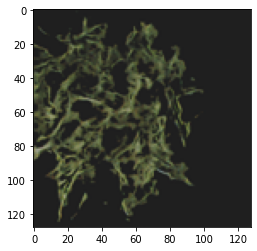

In [56]:
plt.imshow(image)
plt.plot()

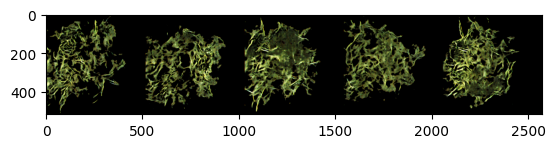

In [ ]:
# generate_images(gen, 5, z_dim, num_images = 5, size = size, device = device)